In [1]:
# Import settings
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

import seaborn as sns
import itertools
from pathlib import Path
from utils import N_palette, D_palette, Ns, Ds, N_color_map, D_color_map, FORMAT_N, FORMAT_D, N_ticks, D_ticks, N_to_N_approx, N_approx_to_N

# Data

In [4]:
df = pd.read_csv('../data/loss_all_exps_post_annealing.csv')
df.head()

,job_name,N,N_approx,D,C,lr,gbsz,beta2,seed,iteration,train_samples,train_tokens,num_of_valid_seq,loss,loss_se
0,dense_130M_xm01_lr0.00025_gbsz16_beta20.99_12B,124455168,130000000.0,1.200000e+10,8.960772e+18,0.00025,16,0.99,1234,183106.0,2929696.0,1.200003e+10,204800.0,2.656725,0.0
1,dense_130M_xm01_lr0.00025_gbsz16_beta20.99_6B,124455168,130000000.0,6.000000e+09,4.480386e+18,0.00025,16,0.99,1234,91553.0,1464848.0,6.000017e+09,204800.0,2.721845,0.0
2,dense_130M_xm01_lr0.00025_gbsz32_beta20.99_12B,124455168,130000000.0,1.200000e+10,8.960772e+18,0.00025,32,0.99,1234,91553.0,2929696.0,1.200003e+10,204800.0,2.656892,0.0
3,dense_130M_xm01_lr0.00025_gbsz32_beta20.99_6B,124455168,130000000.0,6.000000e+09,4.480386e+18,0.00025,32,0.99,1234,45777.0,1464864.0,6.000083e+09,204800.0,2.729814,0.0
4,dense_130M_xm01_lr0.0005_gbsz1024_beta20.99_120B,124455168,130000000.0,1.200000e+11,8.960772e+19,0.00050,1024,0.99,1234,28611.0,29297664.0,1.200032e+11,204800.0,2.556560,0.0


In [5]:
df_best_lr_gbsz = df.loc[df.groupby(["N", "D"])['loss'].idxmin()].reset_index(drop=True)

In [6]:
# ============================================================
# Optimal loss trajectories
# ============================================================

C_grid = np.logspace(
    np.log10(df["C"].min()),
    np.log10(df["C"].max()),
    300,
)

# Parametric Loss Fit

In [7]:
def scaling_law_skaling(X, E, A, alpha, B, beta, k):
    N, D = X

    return E + (A * N**(-alpha) + B * D**(-beta))**k

def scaling_law_chinchilla(X, E, A, alpha, B, beta):
    N, D = X

    return E + A * N**(-alpha) + B * D**(-beta)

In [12]:
# ------------------------------------------------------
# Load Skaling Bootstrap results
# ------------------------------------------------------

skaling_boot = np.load("../data/bootstrap/bootstrap_skalling.npz")
log_params_skaling_boot = skaling_boot["params_bootstrap"]

# Convert each bootstrap sample back to original parameterization
log_E, log_A, alpha, log_B, beta, k = log_params_skaling_boot.T
params_skaling_boot = np.column_stack([np.exp(log_E), np.exp(log_A), alpha, np.exp(log_B), beta, k])

In [13]:
# ============================================================
# Closed-form optimal scaling laws
# ============================================================

def derive_optimal_laws(E, A, alpha, B, beta, k=None):
    gamma_N = beta / (alpha + beta)
    gamma_D = alpha / (alpha + beta)
    K_N = ((alpha * A) / (beta * B * 6**beta)) ** (1 / (alpha + beta))
    K_D = 1 / (6 * K_N)

    if k is None:
        alpha_L = -alpha * beta / (alpha + beta)
        A_L = A * K_N**(-alpha) + B * K_D**(-beta)
    else:
        alpha_L = -alpha * beta * k / (alpha + beta)
        A_L = (A * K_N**(-alpha) + B * K_D**(-beta))**k

    return {
        "E": E,
        "A": A,
        "alpha": alpha,
        "B": B,
        "beta": beta,
        "k": k,
        "gamma_N": gamma_N,
        "gamma_D": gamma_D,
        "K_N": K_N,
        "K_D": K_D,
        "alpha_L": alpha_L,
        "A_L": A_L,
    }


def N_opt(model, C):
    return model["K_N"] * C**model["gamma_N"]


def D_opt(model, C):
    return model["K_D"] * C**model["gamma_D"]


def L_opt(model, C):
    return model["E"] + model["A_L"] * C**model["alpha_L"]


def L_opt_bootstrap(model, C):
    return model["E"][:, None] + model["A_L"][:, None] * C[None, :]**model["alpha_L"][:, None]


# ============================================================
# Bootstrap estimates
# ============================================================

models_boot = {}

# ------------------------------------------------------------
# Skaling
# ------------------------------------------------------------

log_E, log_A, alpha, log_B, beta, k = log_params_skaling_boot.T

boot_skaling = np.column_stack([
    np.exp(log_E),
    np.exp(log_A),
    alpha,
    np.exp(log_B),
    beta,
    k,
])

models_boot["skaling"] = derive_optimal_laws(*boot_skaling.T)

# ============================================================
# Bootstrap optimal loss curves
# ============================================================

L_boot_skaling = L_opt_bootstrap(models_boot["skaling"], C_grid)

print(L_boot_skaling.shape) # shoulld be n_boot x len(C_grid)

# ============================================================
# Bootstrap summaries
# ============================================================
n_boot = L_boot_skaling.shape[0]

L_skaling_med = np.median(L_boot_skaling, axis=0)
L_skaling_mean = np.mean(L_boot_skaling, axis=0)
L_skaling_se = np.std(L_boot_skaling, axis=0, ddof=1) / np.sqrt(n_boot)
L_skaling_lo, L_skaling_hi = np.percentile(L_boot_skaling, [2.5, 97.5], axis=0)

(1000, 300)


In [14]:
assert np.all(np.isfinite(boot_skaling))
assert np.all(boot_skaling[:, 0] > 0)
assert np.all(boot_skaling[:, 1] > 0)
assert np.all(boot_skaling[:, 2] > 0)
assert np.all(boot_skaling[:, 3] > 0)
assert np.all(boot_skaling[:, 4] > 0)
assert np.all(np.isfinite(boot_skaling[:, 5]))
assert np.all(boot_skaling[:, 5] > 0)

In [15]:
def print_optimal_loss_latex_bootstrap_mean(model_boot, label="eq:optimal_loss_scaling"):
    E = np.mean(model_boot["E"])
    A_L = np.mean(model_boot["A_L"])
    alpha_L = np.mean(model_boot["alpha_L"])

    print(r"\begin{equation}")
    print(r"    \begin{aligned}")
    print(fr"    L^\star(C) &= {E:.3f} + {A_L:.3f}\, C^{{{alpha_L:.3f}}},")
    print(r"    \end{aligned}")
    print(fr"\label{{{label}}}")
    print(r"\end{equation}")

In [16]:
print_optimal_loss_latex_bootstrap_mean(models_boot["skaling"], "eq:optimal_loss_scaling_skaling")

\begin{equation}
    \begin{aligned}
    L^\star(C) &= 1.030 + 60.894\, C^{-0.084},
    \end{aligned}
\label{eq:optimal_loss_scaling_skaling}
\end{equation}


In [ ]:
E = np.mean(models_boot["skaling"]["E"])
A_L = np.mean(models_boot["skaling"]["A_L"])
alpha_L = np.mean(models_boot["skaling"]["alpha_L"])

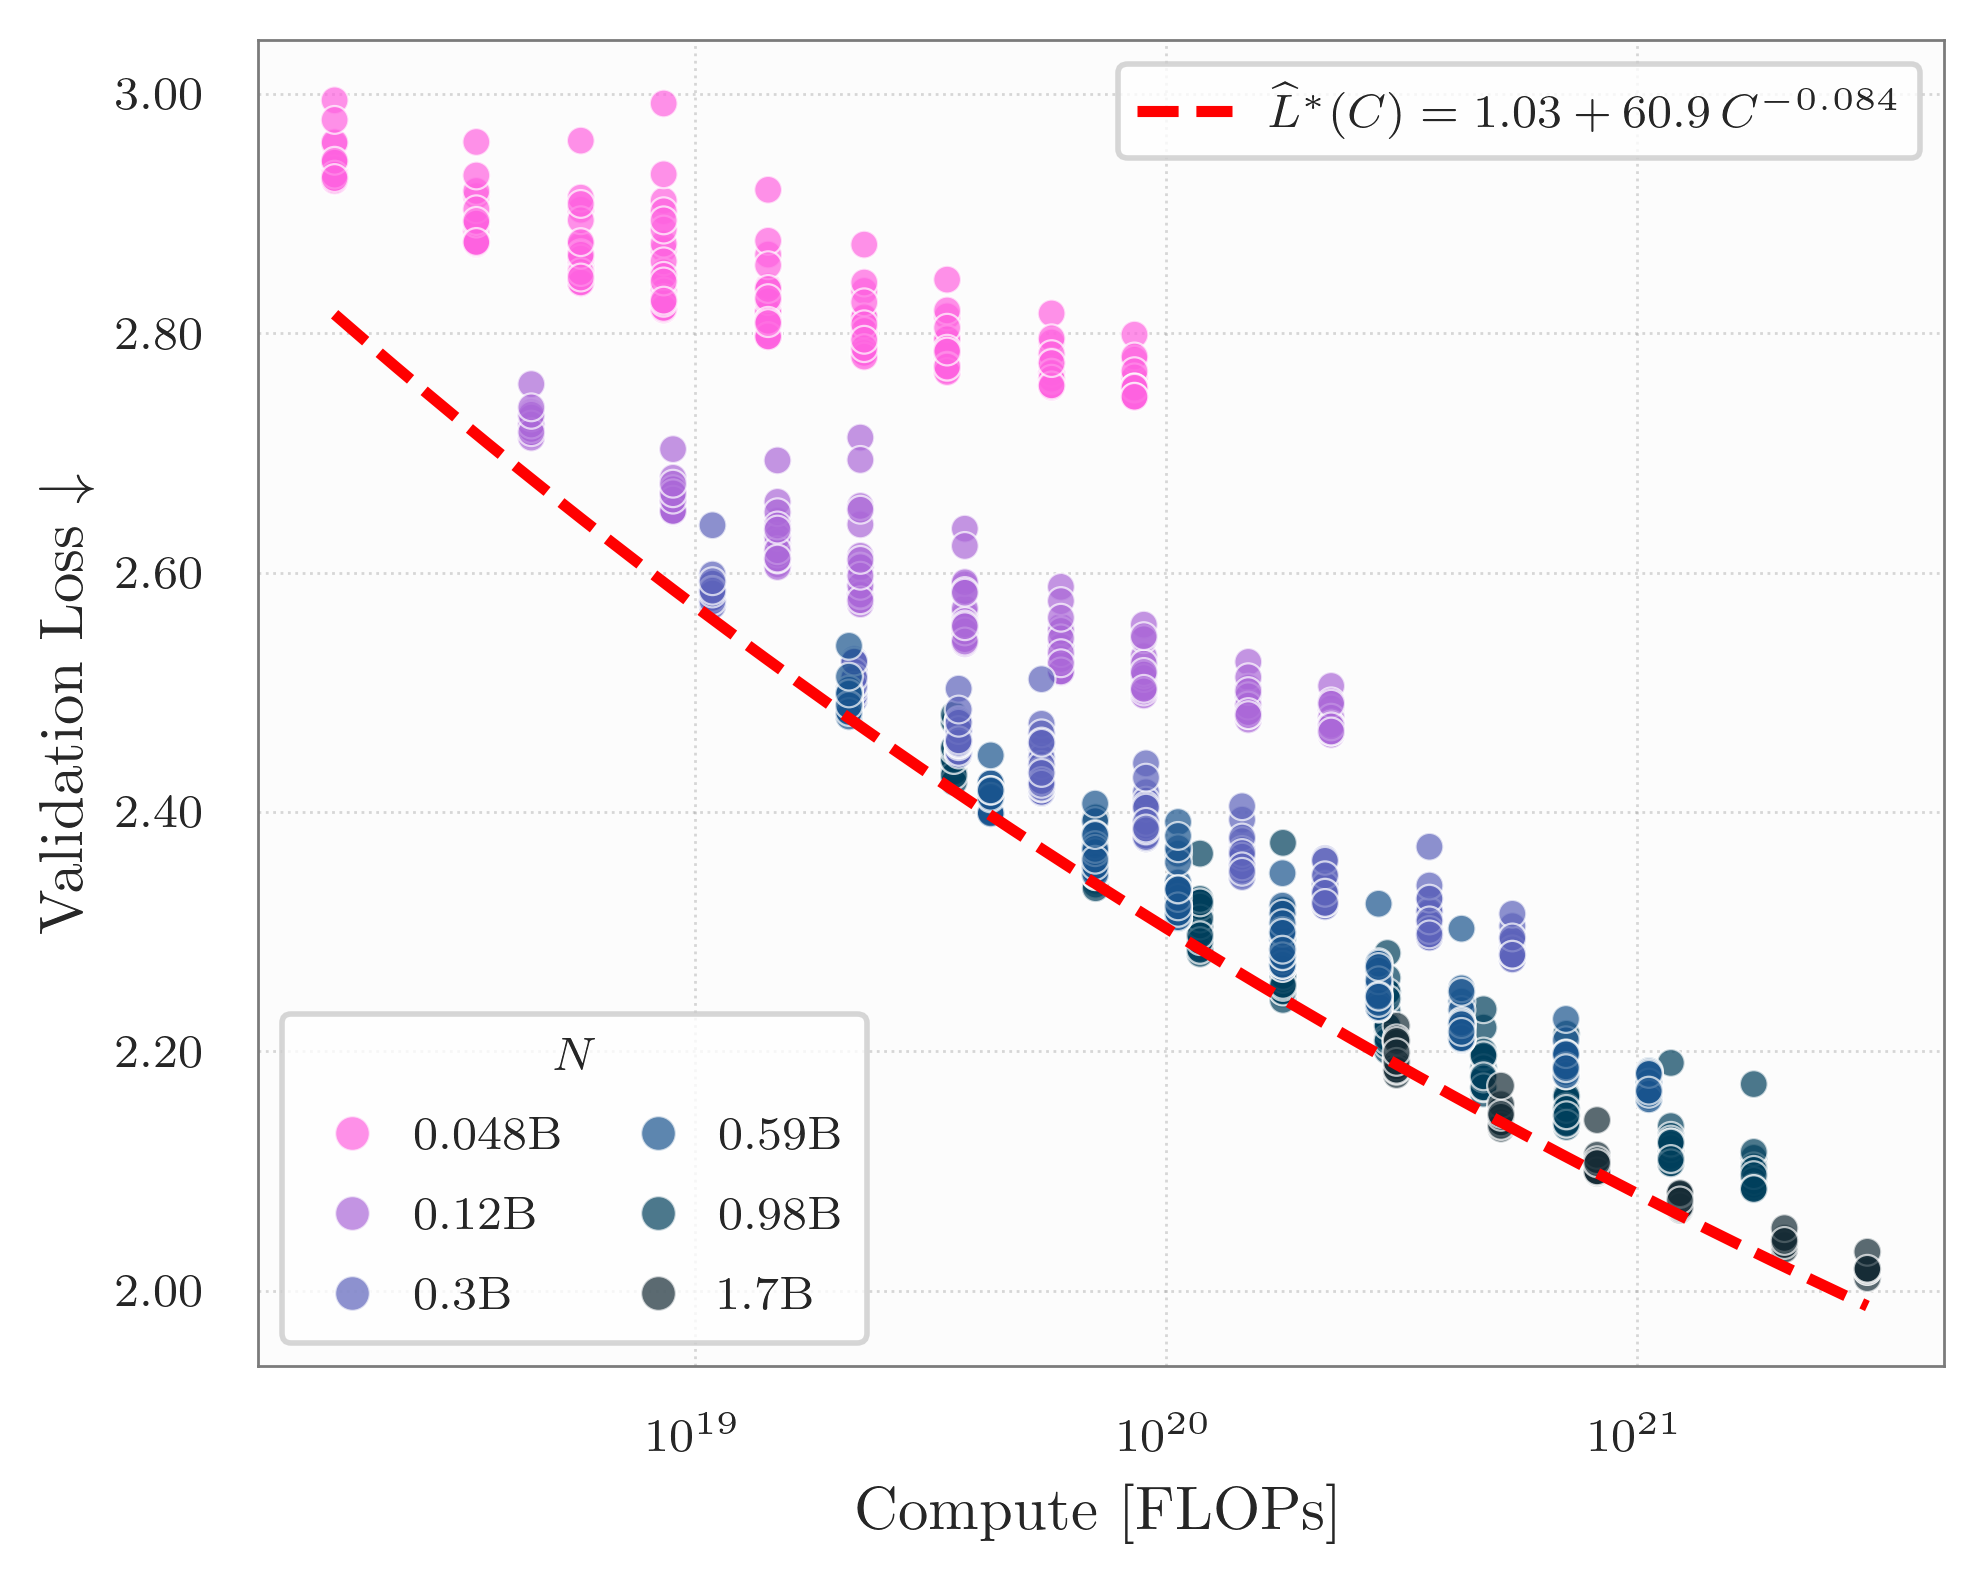

In [19]:
# ============================================================
# Plot — Skaling only
# ============================================================

df_plot = df.copy()

fig, ax = plt.subplots(figsize=(5, 4))

# ------------------------------------------------------------
# Raw measured checkpoints
# ------------------------------------------------------------

sns.scatterplot(
    data=df_plot,
    x="C",
    y="loss",
    hue="N",
    palette=N_color_map,
    legend=True,
    alpha=0.7,
    s=25,
    ax=ax,
)

# ------------------------------------------------------------
# Skaling bootstrap optimal loss envelope
# ------------------------------------------------------------

# label=label=r"Estimated Optimal Loss Scaling Law"
# label = rf"Estimated Compute-Optimal Scaling Law:\\  $\widehat{{L}}^*(C) = {E:.3g} + {A_L:.3g}\,C^{{{alpha_L:.3f}}}$"
label = rf"$\widehat{{L}}^*(C) = {E:.3g} + {A_L:.3g}\,C^{{{alpha_L:.3f}}}$"
sk_line, = ax.plot(
    C_grid,
    L_skaling_mean,
    color="red",
    linewidth=2,
    linestyle="--",
    label=label,
)
# ax.fill_between(
#     C_grid,
#     L_skaling_mean - L_skaling_se,
#     L_skaling_mean + L_skaling_se,
#     color="red",
#     alpha=0.15,
# )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_xlabel("Compute [FLOPs]")
ax.set_ylabel(r"Validation Loss $\downarrow$")

# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

# First len(N_color_map) entries are the N values
n_handles = handles[:len(N_color_map)]
n_labels = [FORMAT_N(float(label)) for label in labels[:len(N_color_map)]]

n_legend = ax.legend(
    n_handles,
    n_labels,
    title=r"$N$",
    loc="lower left",
    frameon=True,
    ncols=2,
    markerscale=1.25,
    labelspacing=0.8,   # vertical spacing
    columnspacing=1.,  # horizontal spacing
    handletextpad=0.3,  # marker ↔ label
    borderpad=0.5,      # padding inside legend
)

ax.add_artist(n_legend)

# Skaling legend
ax.legend(
    [sk_line],
    [label],
    loc="upper right",
    frameon=True,
)

# ax.set_yticks([2.0, 2.5, 3.0])
# ax.set_yticklabels(["2.0", "2.5", "3.0"])

yticks = [2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.2f}" for y in yticks])

# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    "../fig/loss_scaling/loss_vs_C_with_fit.pdf",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()